# NYC Construction Permit Approval Duration
## Baseline Regression

This notebook establishes a baseline linear regression model to predict permit 
approval duration. The focus is on model structure, assumption checking, and 
interpretability rather than predictive accuracy alone.

In [2]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

df = pd.read_csv('permit_model_data.csv')

X = df.drop(columns=['approval_duration'])
y = df['approval_duration']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape, X_test.shape)

(8222, 30) (2056, 30)


#### Model Fit and Evaluation

Fit a baseline ordinary least squares regression model and evaluate performance on the held-out test set using RMSE and R².

In [3]:
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2:.4f}")

RMSE: 51.95
R²: 0.0054


#### Results and Interpretation

The baseline linear regression model yields an R² of 0.005 and RMSE of 51.95 days, 
indicating that the categorical predictors alone explain very little of the variance 
in approval duration. This is consistent with the high variability observed in the 
response variable (std = 52.2 days) and suggests that permit approval time is not 
strongly determined by job type, borough, or permit type in isolation.

These results establish a performance benchmark for comparison with regularized 
and tree-based models in subsequent notebooks.

In [4]:
coefficients = pd.Series(model.coef_, index=X.columns)
print(coefficients.abs().sort_values(ascending=False).head(10))

work_type_FP             22.044990
work_type_CC              9.742054
permit_type_DM            8.988352
work_type_SD              6.598901
work_type_UNKNOWN         6.441894
work_type_SP              4.908393
work_type_PL              4.808222
permit_type_PL            4.808222
job_type_A3               4.616122
borough_STATEN ISLAND     4.408582
dtype: float64


#### Coefficient Analysis

The largest coefficients are associated with `work_type`, particularly `FP` 
(fence/partition) and `CC` (construction equipment), suggesting these permit 
types tend to have longer approval durations relative to the baseline. `permit_type_DM` 
(demolition) and `borough_STATEN ISLAND` also show meaningful coefficients. 

Despite these patterns, the low R² indicates that while these variables show 
some directional signal, they are insufficient to reliably predict approval duration.

#### Coefficient Plot

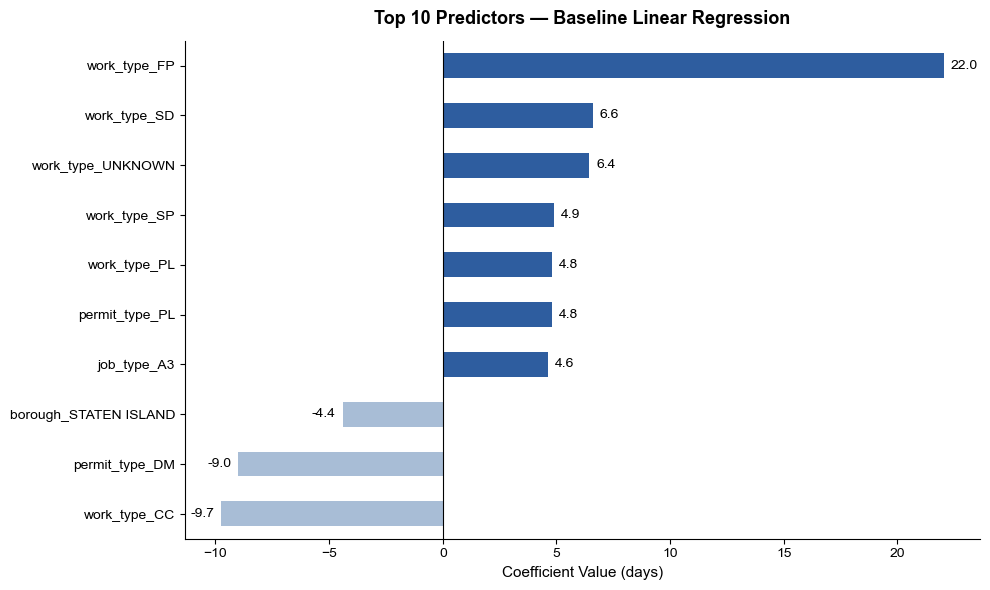

In [5]:
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams['font.family'] = 'Arial'
mpl.rcParams['axes.spines.top'] = False
mpl.rcParams['axes.spines.right'] = False

coefficients = pd.Series(model.coef_, index=X.columns)
top10_coef = coefficients.abs().sort_values(ascending=False).head(10)
top10_coef_signed = coefficients[top10_coef.index].sort_values()

colors = ['#2E5D9F' if v > 0 else '#A8BDD6' for v in top10_coef_signed]

fig, ax = plt.subplots(figsize=(10, 6))
top10_coef_signed.plot(kind='barh', ax=ax, color=colors, width=0.5)

ax.set_xlabel('Coefficient Value (days)', fontsize=11)
ax.set_title('Top 10 Predictors — Baseline Linear Regression', fontsize=13, fontweight='bold', pad=12)
ax.axvline(0, color='black', linewidth=0.8)

for i, v in enumerate(top10_coef_signed):
    if v >= 0:
        ax.text(v + 0.3, i, f'{v:.1f}', va='center', fontsize=10, ha='left')
    else:
        ax.text(v - 0.3, i, f'{v:.1f}', va='center', fontsize=10, ha='right')

plt.tight_layout()
plt.savefig('baseline_coefficients.png', dpi=150, bbox_inches='tight')
plt.show()

#### Summary

The baseline linear regression model establishes a low performance benchmark 
(R² = 0.005, RMSE = 51.95), confirming that categorical permit features alone 
have limited predictive power. Work type emerges as the strongest signal among 
the predictors. Regularization and tree-based methods are explored in subsequent 
notebooks to assess whether model performance can be meaningfully improved.